# 03 - Stereo Reconstruction

Welcome to the most hands-on notebook in this mini stereo reconstruction sequence. In this notebook, you will build the core pieces of a simple stereo matcher yourself and then compare your result against stronger reference methods.

The big idea is simple but very powerful: if we have two cameras looking at the same scene from slightly different positions, nearby points appear shifted more than far-away points. That horizontal shift is called **disparity**. Once we know the disparity, we can turn it into depth and eventually into a 3D point cloud.

We will go step by step:

- start with a **rectified stereo pair**, where corresponding points should lie on the same image row,
- implement a small **patch matching cost** using sum of absolute differences,
- build a **cost volume** that stores candidate matching costs for many disparities,
- use **winner-takes-all** to pick the best disparity at every pixel,
- compare the result to a vectorized reference implementation and OpenCV SGBM,
- optionally run **FoundationStereo**, a learned stereo model,
- convert disparity maps into 3D point clouds and inspect the geometry.

By the end, you should have a practical intuition for why stereo works, where simple block matching breaks, and why disparity errors can become very visible in reconstructed 3D geometry.

This notebook is intentionally implementation-focused, but the goal is not to write the most optimized code. The goal is to make the stereo pipeline feel concrete and understandable.


In [ ]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = "https://github.com/FelTris/camp2_3drecon.git"
REPO_NAME = "camp2_3drecon"


def running_in_colab():
    try:
        import google.colab  # noqa: F401
    except ModuleNotFoundError:
        return False
    return True


if running_in_colab():
    repo = Path("/content") / REPO_NAME
    if not (repo / ".git").exists():
        if repo.exists():
            raise FileExistsError(f"{repo} exists but is not a Git checkout. Remove it or choose another path.")
        subprocess.run(["git", "clone", REPO_URL, str(repo)], check=True)
    os.chdir(repo)
else:
    repo = Path.cwd()
    if repo.name == "notebooks":
        repo = repo.parent

REPO = repo.resolve()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

OUTPUT_ROOT = Path("/content/camp2_outputs") if running_in_colab() else REPO / "outputs"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

mpl_config = OUTPUT_ROOT / ".mplconfig"
mpl_config.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mpl_config))

print("Repository:", REPO)
print("Output root:", OUTPUT_ROOT)


## Install Dependencies

In Colab, run this cell before importing the reconstruction libraries. It installs the Python requirements and clones the external model repositories used by the notebooks. After a successful install, the cell writes a small marker file in Colab's temporary output folder and restarts the runtime once so upgraded packages such as NumPy are loaded cleanly. When you rerun the notebook in the same runtime storage, the marker file makes the install step skip.

Local users can leave `INSTALL_DEPENDENCIES = False` if the environment is already set up.


In [ ]:
RESTART_AFTER_INSTALL = running_in_colab()
INSTALL_DEPENDENCIES = running_in_colab()
INSTALL_SENTINEL = OUTPUT_ROOT / ".reconstruction_stack_installed"
DA3_STREAMING_DIR = REPO / "externals" / "Depth-Anything-3" / "da3_streaming"
FOUNDATION_STEREO_DIR = REPO / "externals" / "FoundationStereo"
REQUIRED_DEPENDENCY_PATHS = [
    DA3_STREAMING_DIR,
    DA3_STREAMING_DIR / "configs" / "base_config.yaml",
    FOUNDATION_STEREO_DIR,
    FOUNDATION_STEREO_DIR / "core" / "foundation_stereo.py",
]


def run_streamed(command, cwd):
    env = os.environ.copy()
    env.setdefault("PYTHONUNBUFFERED", "1")
    env.setdefault("PIP_PROGRESS_BAR", "off")
    print("$ " + " ".join(command), flush=True)
    process = subprocess.Popen(
        command,
        cwd=cwd,
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    assert process.stdout is not None
    for line in process.stdout:
        print(line, end="", flush=True)
    return_code = process.wait()
    if return_code != 0:
        raise subprocess.CalledProcessError(return_code, command)


def missing_dependency_paths():
    return [path for path in REQUIRED_DEPENDENCY_PATHS if not path.exists()]


missing_paths = missing_dependency_paths()
needs_install = INSTALL_DEPENDENCIES and (not INSTALL_SENTINEL.exists() or bool(missing_paths))

if needs_install:
    if INSTALL_SENTINEL.exists() and missing_paths:
        print("Dependency marker exists, but required external files are missing:", flush=True)
        for path in missing_paths:
            print(f"  - {path}", flush=True)
        print("Rerunning the dependency installer.", flush=True)
    run_streamed(["bash", "scripts/install_reconstruction_stack.sh"], cwd=REPO)
    missing_paths = missing_dependency_paths()
    if missing_paths:
        missing_text = "\n".join(f"  - {path}" for path in missing_paths)
        raise FileNotFoundError(f"Installer finished, but required dependency paths are still missing:\n{missing_text}")
    INSTALL_SENTINEL.write_text("ok\n")
    print("\nDependency install completed successfully.", flush=True)
    if RESTART_AFTER_INSTALL:
        print("Restarting the Colab runtime once so updated packages are imported cleanly.", flush=True)
        print("After Colab reconnects, rerun the notebook from the top; this install cell will skip.", flush=True)
        try:
            from google.colab import runtime

            runtime.restart_runtime()
            raise SystemExit("Restarting Colab runtime...")
        except Exception:
            os.kill(os.getpid(), 9)
    else:
        print("Restart your Python kernel before importing the reconstruction libraries.", flush=True)
elif INSTALL_DEPENDENCIES:
    print(f"Using existing dependency install marker: {INSTALL_SENTINEL}")
    print("Required external dependency paths are present.")
    print("Delete this file and rerun the cell if you need to reinstall dependencies.")
else:
    print("Skipping dependency install outside Colab.")
    missing_paths = missing_dependency_paths()
    if missing_paths:
        print("Missing external dependency paths:")
        for path in missing_paths:
            print(f"  - {path}")
    print("Set INSTALL_DEPENDENCIES = True and rerun this cell if your local environment is not set up.")


In [ ]:
import sys

import cv2
import numpy as np
import torch

from camp3d.calibration import depth_to_point_cloud, disparity_to_depth, load_calibration, rectify_pair
from camp3d.data import ScaredSubset
from camp3d.stereo import opencv_sgbm, reference_sad_cost_volume, reference_winner_takes_all, to_gray_float
from camp3d.viz import read_rgb, show_colmap_reconstruction_plotly, show_disparity, show_stereo_pair

device = "cuda" if torch.cuda.is_available() else "cpu"
dataset = ScaredSubset(REPO / "scared_640")
calib = load_calibration(dataset.calibration_json)
print("device:", device)
print("baseline:", calib.baseline, calib.unit)


## Rectified Stereo Pair

Before matching can become easy, the two images need to be **rectified**. Rectification warps the left and right images so that a 3D point appears on the same horizontal image row in both views.

That means we do **not** need to search in every direction for a match. Instead, for a pixel in the left image, we only search along the same row in the right image. This turns a 2D search problem into a much simpler 1D search problem.

The horizontal shift between the two appearances is called **disparity**:

- large disparity usually means the point is close to the cameras,
- small disparity usually means the point is far away,
- zero or invalid disparity often means the point could not be matched reliably.

Take a moment to look at the displayed stereo pair. Some structures should look slightly shifted between the left and right image. That shift is the signal we will use for reconstruction.


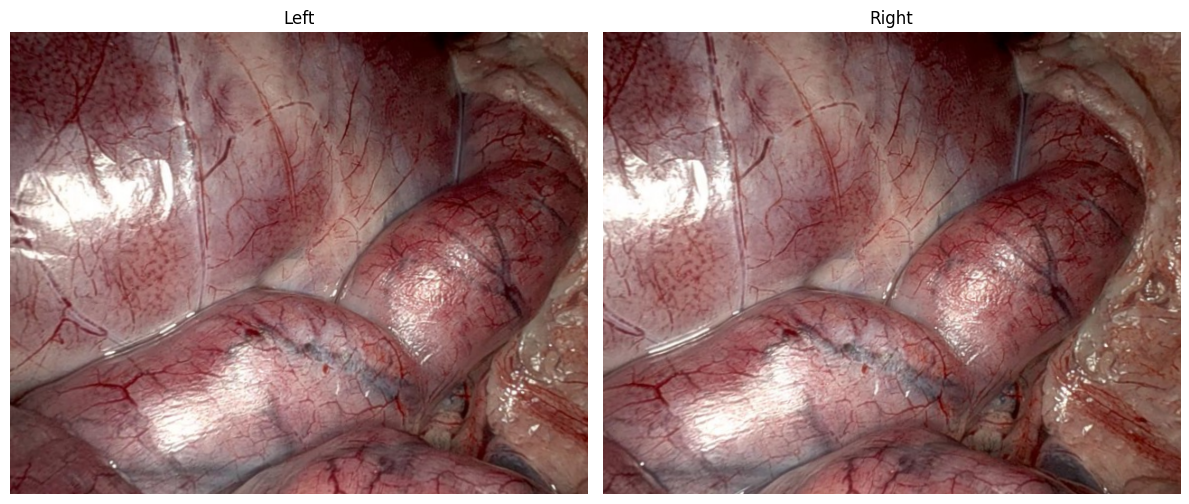

In [5]:
left_path, right_path = dataset.stereo_pairs()[30]
left = read_rgb(left_path)
right = read_rgb(right_path)
left_rect, right_rect, rect = rectify_pair(left, right, calib)
show_stereo_pair(left_rect, right_rect)

## Exercise 1: Patch Matching Cost

Your first task is to implement the most basic building block of stereo matching: comparing two small image patches.

For one pixel `(y, x)` in the left image and one candidate `disparity`, we ask:

> “If this left-image patch was shifted by this disparity, how well would it match the right image?”

We will use **sum of absolute differences**, usually shortened to **SAD**. It is a simple matching cost:

1. take a square patch around `(y, x)` in the left image,
2. take a square patch around `(y, x - disparity)` in the right image,
3. compute the absolute difference between the two patches,
4. sum all differences into one number.

A small SAD value means “these patches look similar”. A large SAD value means “this is probably not the right match”.

Implementation details to keep in mind:

- The patch radius controls the patch size. For `radius = 2`, the patch is `5 x 5`.
- If either patch would leave the image, return `np.inf`. This tells later code that this candidate is invalid.
- You do not need anything fancy here. Straightforward slicing and `np.abs(...).sum()` are enough.

This is deliberately simple. It will fail in real images sometimes, but that is exactly why it is a useful first stereo matcher to understand.


In [6]:
def sad_patch_cost(left_gray, right_gray, y, x, disparity, radius):
    h, w = left_gray.shape
    right_x = x - disparity

    y0 = y - radius
    y1 = y + radius + 1
    left_x0 = x - radius
    left_x1 = x + radius + 1
    right_x0 = right_x - radius
    right_x1 = right_x + radius + 1

    if y0 < 0 or y1 > h:
        return np.inf
    if left_x0 < 0 or left_x1 > w:
        return np.inf
    if right_x0 < 0 or right_x1 > w:
        return np.inf

    left_patch = left_gray[y0:y1, left_x0:left_x1]
    right_patch = right_gray[y0:y1, right_x0:right_x1]
    return np.abs(left_patch - right_patch).sum()


## Exercise 2: Cost Volume

Now we scale the patch matching idea from one pixel and one disparity to **all pixels** and **all candidate disparities**.

A **cost volume** stores the matching cost for every combination of:

- image row `y`,
- image column `x`,
- candidate disparity `d`.

Its shape is:

```text
height x width x max_disparity
```

So `cost_volume[y, x, d]` answers the question:

> “How well does pixel `(y, x)` in the left image match the right image if we shift by disparity `d`?”

For this exercise, implement the most direct version: allocate an array and fill it with calls to your `sad_patch_cost` function. This will not be fast, but it is wonderfully transparent. You should be able to look at the loops and see the whole stereo search happening.

A good mental model is: each pixel gets a small list of candidate costs, one for each possible disparity. Later, we will simply choose the cheapest candidate.


In [7]:
def build_sad_cost_volume(left_gray, right_gray, max_disparity, radius):
    h, w = left_gray.shape
    cost_volume = np.full((h, w, max_disparity), np.inf, dtype=np.float32)

    for y in range(h):
        for x in range(w):
            for d in range(max_disparity):
                cost_volume[y, x, d] = sad_patch_cost(
                    left_gray, right_gray, y, x, d, radius
                )

    return cost_volume


## Exercise 3: Winner-Takes-All

Once the cost volume is filled, each pixel has many possible disparity candidates. The simplest way to turn those costs into a disparity map is called **winner-takes-all**.

For every pixel, choose the disparity with the lowest matching cost:

```text
best disparity = argmin over all candidate costs
```

This is intentionally simple. It treats every pixel independently and does not ask whether neighboring pixels agree. That makes it easy to implement and easy to understand, but it also explains many of its failure cases:

- flat or textureless regions can have many equally plausible matches,
- repetitive patterns can produce the wrong minimum,
- object boundaries can mix foreground and background inside one patch,
- occluded pixels may have no valid match at all.

For this exercise, return the best disparity index at every pixel. If a pixel has no finite costs, set its disparity to `0` so the output remains well-defined.


In [8]:
def winner_takes_all(cost_volume):
    finite = np.isfinite(cost_volume)
    safe_costs = np.where(finite, cost_volume, np.inf)

    disparity = np.argmin(safe_costs, axis=-1).astype(np.float32)
    invalid = ~np.any(finite, axis=-1)
    disparity[invalid] = 0

    return disparity


## Synthetic Checks

Before trying the real stereo image, we run a tiny synthetic test.

Small tests like this are extremely useful because they remove almost all visual complexity. If something fails here, the problem is probably in the indexing, patch boundaries, or `argmin` logic rather than in the stereo image itself.

The toy example creates a small image and a shifted version of it. Since we know the correct shift, we can check whether the implemented functions recover the expected disparity.

Passing these checks does not prove that the full method will look perfect on real data, but it does show that the basic mechanics are working.


In [9]:
toy_left = np.array(
    [[0, 0, 0, 0, 0],
     [0, 1, 2, 3, 0],
     [0, 4, 5, 6, 0],
     [0, 7, 8, 9, 0],
     [0, 0, 0, 0, 0]],
    dtype=np.float32,
)
toy_right = np.roll(toy_left, shift=-1, axis=1)

assert sad_patch_cost(toy_left, toy_right, y=2, x=2, disparity=1, radius=1) == 0
toy_volume = build_sad_cost_volume(toy_left, toy_right, max_disparity=3, radius=1)
toy_disp = winner_takes_all(toy_volume)
assert toy_volume.shape == (5, 5, 3)
assert toy_disp[2, 2] == 1
print("synthetic checks passed")

synthetic checks passed


## Run Your Block Matcher

Now it is time to apply your implementation to a real rectified stereo pair.

The direct implementation uses explicit loops, so it is intentionally run on a smaller image. This keeps the runtime manageable while still showing the behavior of block matching clearly.

Before running the cell, make a quick prediction:

- Which regions have enough texture to match well?
- Which regions look smooth, shiny, repeated, or ambiguous?
- Where might patch matching blur across object boundaries?

After running it, compare your prediction to the disparity visualization. Bright or dark regions are not automatically “good” or “bad”; the important question is whether the disparities are spatially consistent and whether object boundaries make sense.


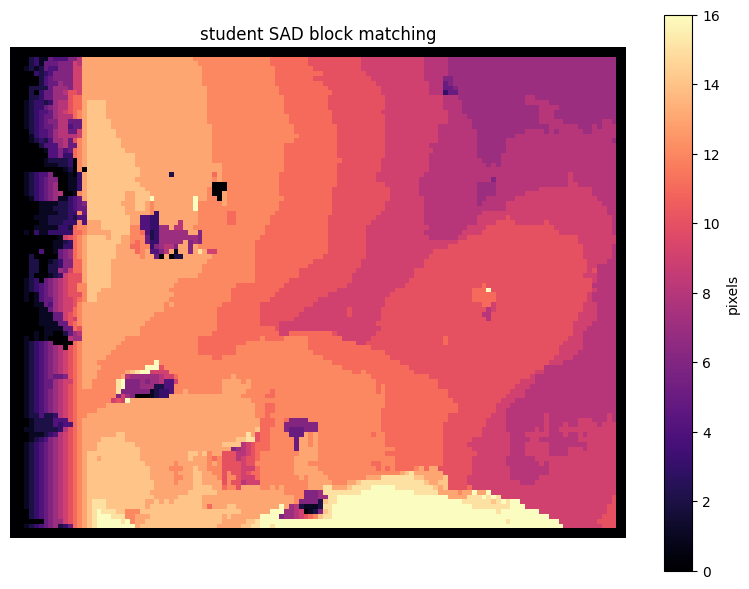

In [14]:
scale = 0.2
small_left = cv2.resize(left_rect, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
small_right = cv2.resize(right_rect, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
left_gray = to_gray_float(small_left)
right_gray = to_gray_float(small_right)

cost_volume = build_sad_cost_volume(left_gray, right_gray, max_disparity=48, radius=2)
student_disp = winner_takes_all(cost_volume)
show_disparity(student_disp, title="student SAD block matching")

## Parameter Lab

The patch radius is one of the most important knobs in simple block matching.

A small patch is very local. It can preserve fine details and sharp boundaries, but it may not contain enough information to identify a unique match. This often creates noisy disparity estimates.

A large patch contains more context. It usually gives more stable matches in textured regions, but it also mixes pixels from different depths. Around object boundaries, this can smear foreground and background together.

In this lab, compare different patch radii and look for the tradeoff:

- smaller radius: more detail, more noise,
- larger radius: smoother output, less detail,
- boundaries: often the first place where the tradeoff becomes visible.

This is a recurring theme in computer vision: adding more context can stabilize predictions, but it can also wash out local structure.


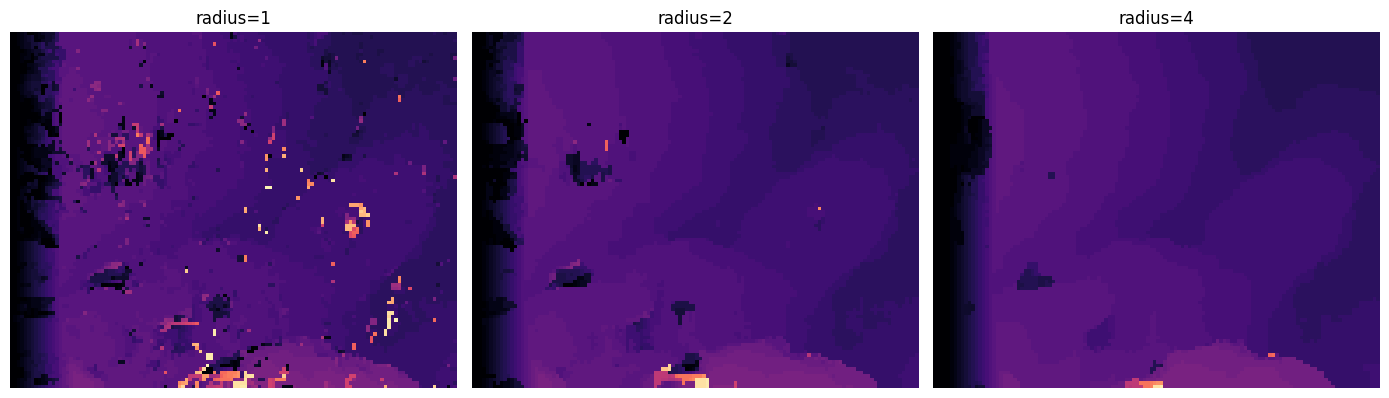

In [15]:
import matplotlib.pyplot as plt

radii = [1, 2, 4]
fig, axes = plt.subplots(1, len(radii), figsize=(14, 4))
for ax, radius in zip(axes, radii):
    volume = reference_sad_cost_volume(left_gray, right_gray, max_disparity=48, radius=radius)
    disparity = reference_winner_takes_all(volume)
    ax.imshow(disparity, cmap="magma", vmin=0, vmax=48)
    ax.set_title(f"radius={radius}")
    ax.axis("off")
plt.tight_layout()

## Vectorized Reference And SGBM

Your implementation is useful for learning, but it is not optimized. The reference SAD implementation computes the same basic idea more efficiently, so we can use it as a faster comparison point.

We also compare against **SGBM**: Semi-Global Block Matching. SGBM still relies on matching evidence between the two images, but it adds a regularization idea: neighboring pixels should usually have compatible disparities. This helps reduce isolated noisy predictions.

However, regularization is not magic. SGBM can still struggle with:

- weak texture,
- reflections or specular highlights,
- occlusions,
- thin structures,
- very sharp depth boundaries.

As you look at the results, try to separate two effects: better local matching and smoother spatial regularization. Both can improve the map, but both can also introduce artifacts.


finite depth pixels: 225530


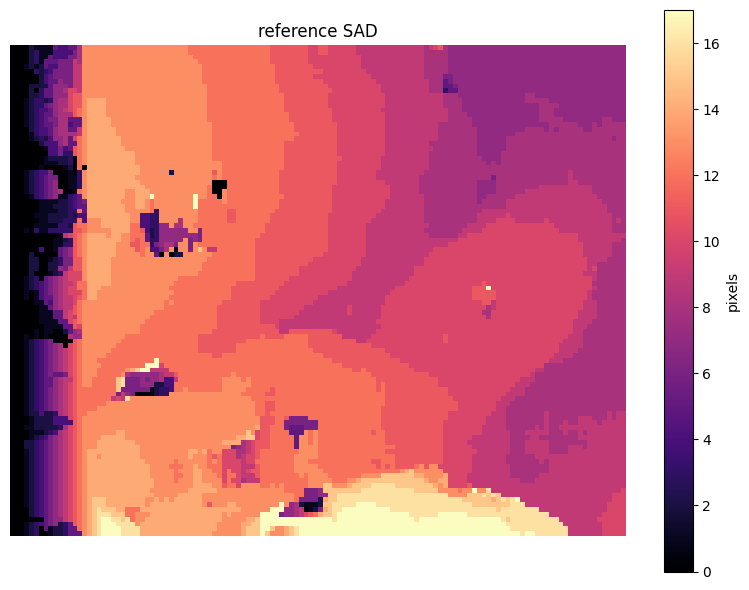

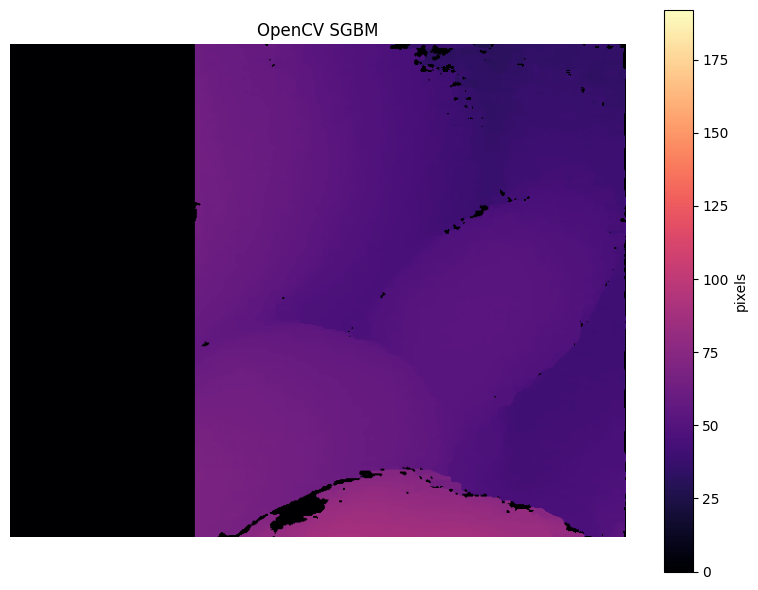

In [16]:
cost_volume_ref = reference_sad_cost_volume(left_gray, right_gray, max_disparity=48, radius=2)
disp_ref = reference_winner_takes_all(cost_volume_ref)
show_disparity(disp_ref, title="reference SAD")

sgbm_disp = opencv_sgbm(to_gray_float(left_rect), to_gray_float(right_rect), max_disparity=192)
show_disparity(sgbm_disp, title="OpenCV SGBM", vmax=192)
depth = disparity_to_depth(sgbm_disp, calib.fx, calib.baseline)
print("finite depth pixels:", np.isfinite(depth).sum())

## Disparity To 3D

A disparity map becomes especially interesting once we convert it into depth.

For a rectified stereo camera, depth is approximately inversely proportional to disparity:

```text
depth ≈ focal_length * baseline / disparity
```

This relationship is important because it is nonlinear. A one-pixel disparity mistake does not always have the same geometric effect.

Intuitively:

- close objects have larger disparity, so the same absolute disparity error is often less dramatic,
- far objects have smaller disparity, so a tiny disparity error can create a large depth error,
- invalid or near-zero disparities can produce extremely large or unusable depths.

This is why a disparity map that looks only “slightly noisy” can turn into a point cloud with very visible geometric artifacts.


In [ ]:
def scaled_intrinsics(K, image_scale):
    K_scaled = K.astype(np.float32).copy()
    K_scaled[0, :] *= image_scale
    K_scaled[1, :] *= image_scale
    return K_scaled


def point_cloud_from_disparity(disparity, rgb, K, baseline, stride=6, max_depth_percentile=98):
    depth = disparity_to_depth(disparity, K[0, 0], baseline)
    finite_depth = depth[np.isfinite(depth)]
    if finite_depth.size:
        max_depth = np.percentile(finite_depth, max_depth_percentile)
        depth = np.where(depth <= max_depth, depth, np.nan)
    return depth_to_point_cloud(depth, rgb, K, stride=stride)


def show_point_cloud(title, key, max_points):
    points, colors = pointclouds[key]
    print(f"{key}: {len(points)} points")
    fig = show_colmap_reconstruction_plotly(
        points,
        colors,
        max_points=max_points,
        point_size=2.0,
        title=title,
    )
    fig.show()


K_rect = rect["P1"][:3, :3].astype(np.float32)
K_small = scaled_intrinsics(K_rect, scale)

student_points, student_colors = point_cloud_from_disparity(
    student_disp,
    small_left,
    K_small,
    calib.baseline,
    stride=2,
)
sgbm_points, sgbm_colors = point_cloud_from_disparity(
    sgbm_disp,
    left_rect,
    K_rect,
    calib.baseline,
    stride=6,
)

pointclouds = {
    "manual_sad": (student_points, student_colors),
    "opencv_sgbm": (sgbm_points, sgbm_colors),
}

for key, (points, _) in pointclouds.items():
    print(f"{key}: {len(points)} points")


## FoundationStereo Model

FoundationStereo is a learned stereo matcher. Instead of using only a hand-designed SAD cost, it has learned stronger visual features and matching priors from data.

Still, the input problem is the same:

```text
rectified left image + rectified right image -> disparity map
```

The learned model should usually be more robust than simple block matching, especially in difficult regions. But it is not guaranteed to be perfect. It can still make mistakes when the scene is unusual, the images differ from its training data, or the geometry is genuinely ambiguous.

Think of this section as a comparison between three levels of stereo matching:

1. **Manual SAD**: simple, transparent, easy to break.
2. **SGBM**: classical matching plus spatial regularization.
3. **FoundationStereo**: learned features and learned matching behavior.

The goal is not only to find the prettiest result, but to understand what each method improves and what kinds of errors remain.


In [20]:
FOUNDATION_STEREO_DIR = REPO / "externals" / "FoundationStereo"
if str(FOUNDATION_STEREO_DIR) not in sys.path:
    sys.path.insert(0, str(FOUNDATION_STEREO_DIR))

from omegaconf import OmegaConf
from core.foundation_stereo import FoundationStereo
from core.utils.utils import InputPadder

ckpt_path = FOUNDATION_STEREO_DIR / "pretrained_models" / "11-33-40" / "model_best_bp2.pth"
cfg_path = ckpt_path.parent / "cfg.yaml"
missing = [path for path in (ckpt_path, cfg_path) if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Place the FoundationStereo 11-33-40 checkpoint files here before running this cell:\n"
        + "\n".join(str(path) for path in missing)
    )

cfg = OmegaConf.load(cfg_path)
cfg.valid_iters = 16
cfg.scale = 0.5
if "vit_size" not in cfg:
    cfg.vit_size = "vits"

foundation_stereo = FoundationStereo(cfg).to(device).eval()
checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
foundation_stereo.load_state_dict(checkpoint["model"])
print(type(foundation_stereo))

Using cache found in /home/felix/.cache/torch/hub/facebookresearch_dinov2_main
using MLP layer as FFN


<class 'core.foundation_stereo.FoundationStereo'>


/tmp/ipykernel_3196074/4232653982.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=device == "cuda"):
/home/felix/CAMP2/externals/FoundationStereo/core/foundation_stereo.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
/home/felix/CAMP2/externals/FoundationStereo/core/submodule.py:390: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/felix/CAMP2/externals/FoundationStereo/core/geometry.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/felix/CAMP2/externals/Foundatio

finite depth pixels: 81920


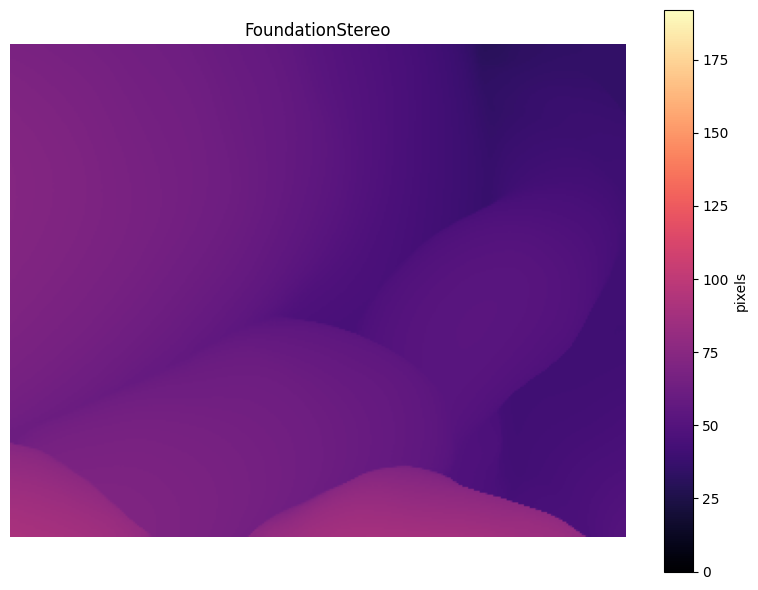

In [21]:
fs_left = cv2.resize(left_rect, None, fx=cfg.scale, fy=cfg.scale, interpolation=cv2.INTER_AREA)
fs_right = cv2.resize(right_rect, None, fx=cfg.scale, fy=cfg.scale, interpolation=cv2.INTER_AREA)

img0 = torch.as_tensor(fs_left, device=device).float()[None].permute(0, 3, 1, 2)
img1 = torch.as_tensor(fs_right, device=device).float()[None].permute(0, 3, 1, 2)
padder = InputPadder(img0.shape, divis_by=32, force_square=False)
img0_pad, img1_pad = padder.pad(img0, img1)

with torch.no_grad(), torch.cuda.amp.autocast(enabled=device == "cuda"):
    fs_disp = foundation_stereo.forward(img0_pad, img1_pad, iters=cfg.valid_iters, test_mode=True)
fs_disp = padder.unpad(fs_disp.float()).cpu().numpy().reshape(fs_left.shape[:2])
fs_disp_full = fs_disp / cfg.scale

show_disparity(fs_disp_full, title="FoundationStereo", vmax=192)
fs_depth = disparity_to_depth(fs_disp_full, calib.fx, calib.baseline)
print("finite depth pixels:", np.isfinite(fs_depth).sum())

## Compare Point Clouds

The disparity maps are useful on their own, but the 3D point clouds make the consequences of stereo errors much easier to see.

All three point clouds use the same rectified left camera frame, so the comparison is mostly about the quality of the estimated disparity maps.

Things to look for:

- Does the overall shape of the scene make sense?
- Are surfaces smooth where they should be smooth?
- Do object boundaries stay crisp or become fuzzy?
- Are there flying points caused by bad disparities?
- Which method produces the most complete cloud?
- Which method produces the most believable geometry?

The manual matcher runs at lower resolution, so expect it to look coarser and less complete. That is okay. Its purpose is to make the mechanics of stereo reconstruction understandable.


In [ ]:
show_point_cloud(
    "Manual SAD point cloud",
    "manual_sad",
    max_points=30_000,
)


In [ ]:
show_point_cloud(
    "OpenCV SGBM point cloud",
    "opencv_sgbm",
    max_points=60_000,
)


In [ ]:
fs_points, fs_colors = point_cloud_from_disparity(
    fs_disp_full,
    left_rect,
    K_rect,
    calib.baseline,
    stride=6,
)
pointclouds["foundation_stereo"] = (fs_points, fs_colors)

show_point_cloud(
    "FoundationStereo point cloud",
    "foundation_stereo",
    max_points=60_000,
)


## Discussion

Use these questions to reflect on what you observed. There is not always one perfect answer here; the goal is to connect visual artifacts back to the stereo matching pipeline.

1. **Where did SAD fail first?**  
   Look for textureless regions, repeated patterns, specular highlights, occlusion boundaries, and thin structures. Why are these difficult for local patch matching?

2. **What changed when the patch radius increased?**  
   Did the result become smoother? Did boundaries become less sharp? Where did more context help, and where did it hurt?

3. **Which artifacts remained in SGBM?**  
   SGBM adds regularization, but it still depends on image evidence. Which errors were reduced, and which ones were still visible?

4. **Which failure cases remain for FoundationStereo?**  
   Learned models are stronger, but not magic. Where does the model still seem uncertain or geometrically inconsistent?

5. **How do disparity errors become geometry errors?**  
   Try to explain how a wrong disparity value changes the estimated depth, and why small disparity mistakes can produce large 3D artifacts for far-away points.

A good final takeaway is: stereo reconstruction is not just about finding matches. It is about finding matches that are accurate enough for geometry.
